# Climate Risk Analysis Project.

In [5]:
import pandas as pd
data=pd.read_csv(r"C:\Users\HP\OneDrive\Documentos\#MR.MUNYI\precipitation_mean_max_min_temp_1901_2020_en.csv")
print(data.head(10))

  Month  MinTemperature   MeanTemperature  MaxTemperature  Precipitation  \
0   Jan            15.86            19.77           23.72          33.59   
1   Feb            16.79            20.69           24.63          28.86   
2   Mar            16.74            22.18           27.68          42.81   
3   Apr            21.32            25.38           29.48          67.88   
4   May            23.07            26.96           30.90         176.59   
5   Jun            23.53            27.18           30.88         227.04   
6   Jul            23.71            27.17           30.67         256.11   
7   Aug            23.45            26.97           30.55         264.96   
8   Sep            22.71            26.20           29.74         274.86   
9   Oct            21.10            24.69           28.33         228.44   

      Period  Level  
0  1901-1930      1  
1  1901-1930      2  
2  1901-1930      3  
3  1901-1930      4  
4  1901-1930      5  
5  1901-1930      6  
6  1901-1

In [3]:
## Checking the columns

print(data.columns)

Index(['Month', 'MinTemperature ', 'MeanTemperature', 'MaxTemperature',
       'Precipitation', 'Period', 'Level'],
      dtype='object')


# 1. Cleaning the data.


In [4]:
# Checking the missing values.

print(data.isnull().sum())

Month              0
MinTemperature     0
MeanTemperature    0
MaxTemperature     0
Precipitation      0
Period             0
Level              0
dtype: int64


# 2. Convert Month to Numbers

In [6]:
# Machine learning models prefer numbers.

month_map = {
"Jan":1,"Feb":2,"Mar":3,"Apr":4,"May":5,"Jun":6,
"Jul":7,"Aug":8,"Sep":9,"Oct":10,"Nov":11,"Dec":12
}

data["Month"] = data["Month"].map(month_map)

# 3. Climate Trend Visualisation.

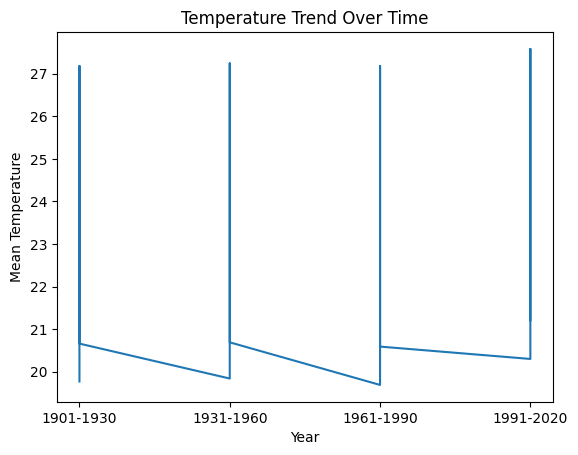

In [8]:
import matplotlib.pyplot as plt

plt.plot(data["Period"], data["MeanTemperature"])
plt.title("Temperature Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Mean Temperature")
plt.show()

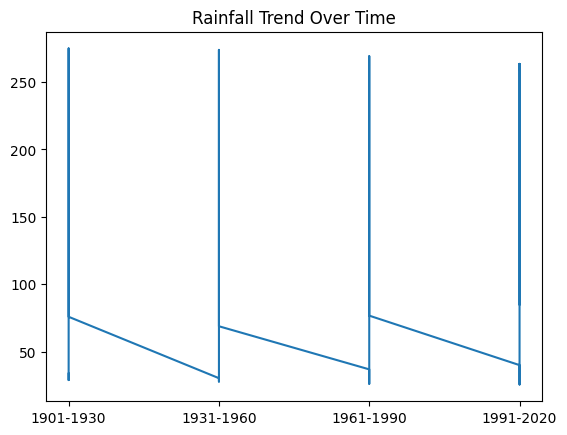

In [9]:
## Rainfall Trend~ predicting drough $ extreme rainfall years.
plt.plot(data["Period"], data["Precipitation"])
plt.title("Rainfall Trend Over Time")
plt.show()

# 4. Relationship between rainfall and Temperature.

<Axes: xlabel='MeanTemperature', ylabel='Precipitation'>

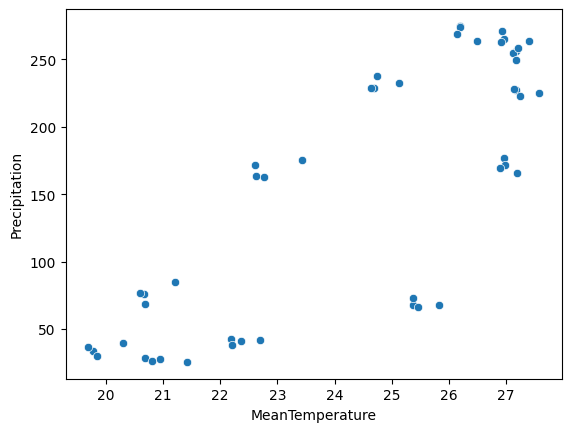

In [11]:
## How temperature affects rainfall.
import seaborn as sns

sns.scatterplot(x=data["MeanTemperature"], y=data["Precipitation"])

# 5. Rainfall prediction model

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = data[["MeanTemperature","MaxTemperature"]]
y = data["Precipitation"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# 6.Testing the prediction.

In [18]:
prediction = model.predict(X_test)

print(prediction[:5])

[229.44864417 228.89387763 238.01372322 221.58867766 159.88915447]


# 7. Model Accuracy 

In [19]:
from sklearn.metrics import r2_score

print(r2_score(y_test,prediction))  ## since the ouput is 0.6394 , the prediction is ~ 64% prediction accuracy.

0.6394537685824464


# 8. Climate Risk Detection.

In [20]:
## Possible flood months.
data[data["Precipitation"] > 200]

## Drought detection.
data[data["Precipitation"] < 20]

,Month,MinTemperature,MeanTemperature,MaxTemperature,Precipitation,Period,Level


# 9. Visualize Climate Risk.

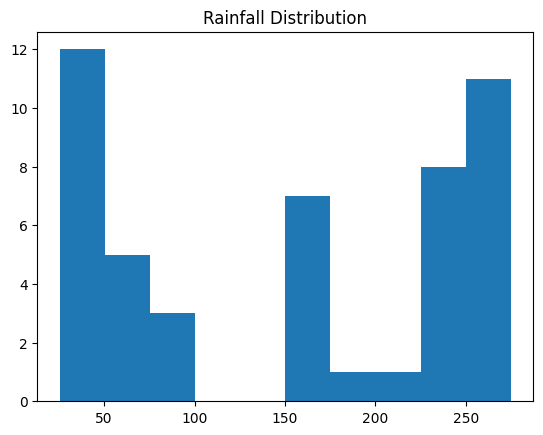

In [21]:
plt.hist(data["Precipitation"])
plt.title("Rainfall Distribution")
plt.show()